# Monitor — YF model *in silico* X-scan

Builds `Xscan.csv` from `TableS10_X-scan_oriDATA.xlsx`.

Output schema matches `260617_test_ESMFold2/benchmark/positives/AF3_class_I.csv`:

`id, cdr3_TRA, cdr3_TRB, TRAV, TRAJ, TRBV, TRBJ, species, peptide, MHC_allele_a`

plus two extra columns: **`ActivationScore`** (experimental read-out) and `tcr` (source sheet,
kept for grouping — drop it if the downstream builder is strict about columns).

Each xlsx sheet is one TCR (19 aa x 9 positions = 171 rows). The 9 rows per sheet where the
substituted residue equals the wild-type residue carry no `ActivationScore` and reproduce the
WT peptide; they are collapsed into a single WT row per TCR (see `INCLUDE_WT`).

In [1]:
import pandas as pd
from pathlib import Path

WD   = Path("/Users/roessner/Documents/PostDoc/Data/261001_YF_model_in_silico_Xscan")
XLSX = WD / "TableS10_X-scan_oriDATA.xlsx"
OUT  = WD / "Xscan.csv"

MHC_ALLELE_A = "HLA_A0201"
SPECIES      = "HomoSapiens"

# Keep one wild-type peptide row per TCR (ActivationScore = NA).
INCLUDE_WT = True

# Per-sheet TCR chain definitions.
TCRS = {
    "TCR_YF":  dict(TRAV="TRAV12-2", cdr3_TRA="CAVGDDKIIF",  TRAJ="TRAJ30",
                    TRBV="TRBV28",   cdr3_TRB="CASTPQTAYEQYF", TRBJ="TRBJ2-7"),
    "TCR_YF2": dict(TRAV="TRAV12-2", cdr3_TRA="CAVNPDKIIF",  TRAJ="TRAJ30",
                    TRBV="TRBV4-2",  cdr3_TRB="CASSQEDRGPEKLFF", TRBJ="TRBJ1-4"),
    "TCR_YF3": dict(TRAV="TRAV12-2", cdr3_TRA="CAAGDDKIIF",  TRAJ="TRAJ30",
                    TRBV="TRBV29-1", cdr3_TRB="CSVATSGGSNEQFF", TRBJ="TRBJ2-1"),
}

COLS = ["id","cdr3_TRA","cdr3_TRB","TRAV","TRAJ","TRBV","TRBJ",
        "species","peptide","MHC_allele_a","ActivationScore","tcr"]

## 1. Read sheets and check assumptions

In [2]:
xl = pd.ExcelFile(XLSX)
print("sheets in file:", xl.sheet_names)

missing = set(TCRS) - set(xl.sheet_names)
assert not missing, f"sheets defined but absent from xlsx: {missing}"
extra = set(xl.sheet_names) - set(TCRS)
if extra:
    print(f"WARNING: sheets present but not defined, skipped: {sorted(extra)}")

raw = {}
for sheet in TCRS:
    df = xl.parse(sheet)
    raw[sheet] = df
    wt = df.loc[df.ActivationScore.isna(), "epitope"].unique()
    print(f"{sheet:8s} rows={len(df):4d}  aa={df.Aa.nunique()}  pos={df.Position.nunique()}  "
          f"unique_peptides={df.epitope.nunique():4d}  NA_score={df.ActivationScore.isna().sum()}  WT={wt}")
    assert set(df.epitope.str.len()) == {9}, f"{sheet}: non-9mer peptide present"

sheets in file: ['TCR_YF', 'TCR_YF2', 'TCR_YF3']
TCR_YF   rows= 171  aa=19  pos=9  unique_peptides= 163  NA_score=9  WT=<StringArray>
['LLWNGPMAV']
Length: 1, dtype: str
TCR_YF2  rows= 171  aa=19  pos=9  unique_peptides= 163  NA_score=9  WT=<StringArray>
['LLWNGPMAV']
Length: 1, dtype: str
TCR_YF3  rows= 171  aa=19  pos=9  unique_peptides= 163  NA_score=9  WT=<StringArray>
['LLWNGPMAV']
Length: 1, dtype: str


## 2. Assemble one table per TCR

In [3]:
records = []

for sheet, chains in TCRS.items():
    df = raw[sheet].copy()

    # Rows with no ActivationScore are the WT-for-WT substitutions -> the WT peptide.
    is_wt = df.ActivationScore.isna()
    wt_peptides = df.loc[is_wt, "epitope"].unique()
    assert len(wt_peptides) <= 1, f"{sheet}: ambiguous WT peptide {wt_peptides}"

    mut = df.loc[~is_wt, ["epitope", "ActivationScore"]].copy()
    assert not mut.epitope.duplicated().any(), f"{sheet}: duplicated mutant peptide"

    if INCLUDE_WT and len(wt_peptides) == 1:
        mut = pd.concat(
            [pd.DataFrame({"epitope": wt_peptides, "ActivationScore": [pd.NA]}), mut],
            ignore_index=True,
        )

    block = pd.DataFrame({
        "cdr3_TRA":        chains["cdr3_TRA"],
        "cdr3_TRB":        chains["cdr3_TRB"],
        "TRAV":            chains["TRAV"],
        "TRAJ":            chains["TRAJ"],
        "TRBV":            chains["TRBV"],
        "TRBJ":            chains["TRBJ"],
        "species":         SPECIES,
        "peptide":         mut.epitope.values,
        "MHC_allele_a":    MHC_ALLELE_A,
        "ActivationScore": mut.ActivationScore.values,
        "tcr":             sheet,
    })
    records.append(block)
    print(f"{sheet:8s} -> {len(block):4d} rows (WT included: {INCLUDE_WT and len(wt_peptides)==1})")

xscan = pd.concat(records, ignore_index=True)
xscan.insert(0, "id", [f"tcr_{i:04d}" for i in range(1, len(xscan) + 1)])
xscan = xscan[COLS]
print("\ntotal rows:", len(xscan))
xscan.head()

TCR_YF   ->  163 rows (WT included: True)
TCR_YF2  ->  163 rows (WT included: True)
TCR_YF3  ->  163 rows (WT included: True)

total rows: 489


,id,cdr3_TRA,cdr3_TRB,TRAV,TRAJ,TRBV,TRBJ,species,peptide,MHC_allele_a,ActivationScore,tcr
0,tcr_0001,CAVGDDKIIF,CASTPQTAYEQYF,TRAV12-2,TRAJ30,TRBV28,TRBJ2-7,HomoSapiens,LLWNGPMAV,HLA_A0201,<NA>,TCR_YF
1,tcr_0002,CAVGDDKIIF,CASTPQTAYEQYF,TRAV12-2,TRAJ30,TRBV28,TRBJ2-7,HomoSapiens,KLWNGPMAV,HLA_A0201,99.73,TCR_YF
2,tcr_0003,CAVGDDKIIF,CASTPQTAYEQYF,TRAV12-2,TRAJ30,TRBV28,TRBJ2-7,HomoSapiens,LKWNGPMAV,HLA_A0201,0.08,TCR_YF
3,tcr_0004,CAVGDDKIIF,CASTPQTAYEQYF,TRAV12-2,TRAJ30,TRBV28,TRBJ2-7,HomoSapiens,LLKNGPMAV,HLA_A0201,-0.06,TCR_YF
4,tcr_0005,CAVGDDKIIF,CASTPQTAYEQYF,TRAV12-2,TRAJ30,TRBV28,TRBJ2-7,HomoSapiens,LLWKGPMAV,HLA_A0201,12.38,TCR_YF


## 3. Validate against the reference schema

In [4]:
REF = Path("/Users/roessner/Documents/PostDoc/Data/260617_test_ESMFold2/"
            "benchmark/positives/AF3_class_I.csv")

ref_cols = list(pd.read_csv(REF, nrows=0).columns)
print("reference columns:", ref_cols)
print("our columns     :", list(xscan.columns))

assert list(xscan.columns[:len(ref_cols)]) == ref_cols, "leading columns deviate from reference"
assert xscan.id.is_unique, "ids not unique"
assert not xscan.peptide.isna().any(), "missing peptide"
assert xscan.groupby("tcr").peptide.apply(lambda s: s.is_unique).all(), "peptide repeated within a TCR"

print("\nrows per TCR:")
print(xscan.tcr.value_counts().sort_index().to_string())
print("\nActivationScore: NA =", int(xscan.ActivationScore.isna().sum()),
      "| min =", xscan.ActivationScore.min(), "| max =", xscan.ActivationScore.max())

reference columns: ['id', 'cdr3_TRA', 'cdr3_TRB', 'TRAV', 'TRAJ', 'TRBV', 'TRBJ', 'species', 'peptide', 'MHC_allele_a']
our columns     : ['id', 'cdr3_TRA', 'cdr3_TRB', 'TRAV', 'TRAJ', 'TRBV', 'TRBJ', 'species', 'peptide', 'MHC_allele_a', 'ActivationScore', 'tcr']

rows per TCR:
tcr
TCR_YF     163
TCR_YF2    163
TCR_YF3    163

ActivationScore: NA = 3 | min = -0.17 | max = 180.69


## 4. Write `Xscan.csv`

In [5]:
xscan.to_csv(OUT, index=False)
print("wrote", OUT, f"({len(xscan)} rows, {len(xscan.columns)} columns)")
print(OUT.read_text().split("\n")[0])
pd.read_csv(OUT).head()

wrote /Users/roessner/Documents/PostDoc/Data/261001_YF_model_in_silico_Xscan/Xscan.csv (489 rows, 12 columns)
id,cdr3_TRA,cdr3_TRB,TRAV,TRAJ,TRBV,TRBJ,species,peptide,MHC_allele_a,ActivationScore,tcr


,id,cdr3_TRA,cdr3_TRB,TRAV,TRAJ,TRBV,TRBJ,species,peptide,MHC_allele_a,ActivationScore,tcr
0,tcr_0001,CAVGDDKIIF,CASTPQTAYEQYF,TRAV12-2,TRAJ30,TRBV28,TRBJ2-7,HomoSapiens,LLWNGPMAV,HLA_A0201,NaN,TCR_YF
1,tcr_0002,CAVGDDKIIF,CASTPQTAYEQYF,TRAV12-2,TRAJ30,TRBV28,TRBJ2-7,HomoSapiens,KLWNGPMAV,HLA_A0201,99.73,TCR_YF
2,tcr_0003,CAVGDDKIIF,CASTPQTAYEQYF,TRAV12-2,TRAJ30,TRBV28,TRBJ2-7,HomoSapiens,LKWNGPMAV,HLA_A0201,0.08,TCR_YF
3,tcr_0004,CAVGDDKIIF,CASTPQTAYEQYF,TRAV12-2,TRAJ30,TRBV28,TRBJ2-7,HomoSapiens,LLKNGPMAV,HLA_A0201,-0.06,TCR_YF
4,tcr_0005,CAVGDDKIIF,CASTPQTAYEQYF,TRAV12-2,TRAJ30,TRBV28,TRBJ2-7,HomoSapiens,LLWKGPMAV,HLA_A0201,12.38,TCR_YF


---

# Analysis of the predictions

`output.csv` holds the summary metrics, `metrics/<id>.csv` the per-structure detail
(scalars, per-chain pLDDT, the chain-pair ipTM matrix, per-residue pLDDT) and
`models/<id>.cif` the structures.

The question: **do any predicted confidence metrics track the experimental
`ActivationScore`?** If they do, the pipeline can triage X-scan variants
*in silico*; if they do not, that is the result worth knowing before scaling up.

## 5. Parse the per-structure metrics

In [6]:
import numpy as np
import re
from io import StringIO
from itertools import combinations

MET_DIR = WD / "metrics"
OUTPUT  = WD / "output.csv"

def parse_metrics(path):
    """Flatten one metrics/<id>.csv (4 blank-line-separated sections) to a dict."""
    groups, cur = [], []
    for line in path.read_text().splitlines():
        if line.strip() == "":
            if cur: groups.append(cur); cur = []
        else:
            cur.append(line)
    if cur: groups.append(cur)

    out, seen = {}, set()
    for g in groups:
        head = g[0]
        if head == "metric,value":
            seen.add("scalars")
            for row in g[1:]:
                k, v = row.split(",", 1)
                out[k] = v
        elif head.startswith("chain_id,"):
            seen.add("chains")
            df = pd.read_csv(StringIO("\n".join(g)))
            for _, r in df.iterrows():
                out[f"plddt_{r.chain_label}"]     = r.plddt_mean
                out[f"plddt_min_{r.chain_label}"] = r.plddt_min
        elif head == "pair_chains_iptm":
            seen.add("pairs")
            df = pd.read_csv(StringIO("\n".join(g[1:])), index_col=0)
            # The matrix is not exactly symmetric; average the two off-diagonals.
            for a, b in combinations(df.index, 2):
                out[f"iptm_{a}_{b}"] = (df.loc[a, b] + df.loc[b, a]) / 2
        elif head.startswith("token_index,"):
            seen.add("tokens")
            df = pd.read_csv(StringIO("\n".join(g)))
            pep = df[df.chain_label == "PEPTIDE"].reset_index(drop=True)
            out["pep_len"] = len(pep)
            for i, r in pep.iterrows():
                out[f"pep_plddt_P{i + 1}"] = r.plddt
        else:
            raise ValueError(f"{path.name}: unrecognised section {head!r}")

    missing = {"scalars", "chains", "pairs", "tokens"} - seen
    assert not missing, f"{path.name}: missing sections {missing}"
    return out

rows = []
for f in sorted(MET_DIR.glob("*.csv")):
    rows.append(parse_metrics(f))

met = pd.DataFrame(rows)
for c in met.columns:
    if c != "id":
        met[c] = pd.to_numeric(met[c], errors="coerce")

assert (met.pep_len == 9).all(), "unexpected peptide length in a model"
print("parsed", len(met), "metrics files;", met.shape[1], "features")
print([c for c in met.columns if not c.startswith("pep_plddt_P")])

parsed 489 metrics files; 44 features
['id', 'seed', 'sample_idx', 'fold_time_seconds', 'ptm', 'iptm', 'plddt_mean', 'plddt_median', 'plddt_min', 'plddt_max', 'pae_mean', 'iptm_pair_mean', 'total_tokens', 'total_atoms', 'plddt_MHC', 'plddt_min_MHC', 'plddt_TCRA', 'plddt_min_TCRA', 'plddt_TCRB', 'plddt_min_TCRB', 'plddt_B2M', 'plddt_min_B2M', 'plddt_PEPTIDE', 'plddt_min_PEPTIDE', 'iptm_MHC_TCRA', 'iptm_MHC_TCRB', 'iptm_MHC_B2M', 'iptm_MHC_PEPTIDE', 'iptm_TCRA_TCRB', 'iptm_TCRA_B2M', 'iptm_TCRA_PEPTIDE', 'iptm_TCRB_B2M', 'iptm_TCRB_PEPTIDE', 'iptm_B2M_PEPTIDE', 'pep_len']


In [7]:
# Cross-check the parsed scalars against output.csv, then add derived features.
out = pd.read_csv(OUTPUT).rename(columns={"ID": "id"})
chk = met.merge(out, on="id", suffixes=("_parsed", "_out"))
assert len(chk) == len(met) == len(out), "id mismatch between metrics/ and output.csv"
for c in ["iptm", "ptm", "plddt_mean", "iptm_pair_mean"]:
    d = (chk[f"{c}_parsed"] - chk[f"{c}_out"]).abs().max()
    assert d < 1e-6, f"{c}: metrics/ and output.csv disagree (max |diff| {d})"
print("metrics/ and output.csv agree on all shared scalars")

# Mean ipTM of the peptide against the two TCR chains - the interface of interest.
met["iptm_pep_tcr"] = met[["iptm_TCRA_PEPTIDE", "iptm_TCRB_PEPTIDE"]].mean(axis=1)
met["pep_plddt_min_pos"] = met[[f"pep_plddt_P{i}" for i in range(1, 10)]].min(axis=1)

metrics/ and output.csv agree on all shared scalars


## 6. Join to the experiment and annotate each mutation

In [8]:
xs = pd.read_csv(OUT)   # Xscan.csv, written above

AA3TO1 = {"ALA":"A","ARG":"R","ASN":"N","ASP":"D","CYS":"C","GLN":"Q","GLU":"E",
          "GLY":"G","HIS":"H","ILE":"I","LEU":"L","LYS":"K","MET":"M","PHE":"F",
          "PRO":"P","SER":"S","THR":"T","TRP":"W","TYR":"Y","VAL":"V"}

# Wild-type peptide = the one row per TCR with no ActivationScore.
wt_pep = xs.loc[xs.ActivationScore.isna(), "peptide"].unique()
assert len(wt_pep) == 1, f"expected a single WT peptide, got {wt_pep}"
WT = wt_pep[0]
print("wild-type peptide:", WT)

def annotate(pep):
    diffs = [(i + 1, WT[i], pep[i]) for i in range(len(WT)) if pep[i] != WT[i]]
    if not diffs:
        return pd.Series({"is_wt": True, "mut_pos": np.nan, "wt_aa": np.nan, "mut_aa": np.nan})
    assert len(diffs) == 1, f"{pep}: expected a single substitution, found {diffs}"
    p, w, m = diffs[0]
    return pd.Series({"is_wt": False, "mut_pos": p, "wt_aa": w, "mut_aa": m})

dat = pd.concat([xs, xs.peptide.apply(annotate)], axis=1).merge(met, on="id", how="left")
assert dat.iptm.notna().all(), "some Xscan rows have no prediction"
assert dat.is_wt.sum() == dat.tcr.nunique(), "expected exactly one WT row per TCR"

# Every non-WT row must carry a score, and vice versa.
assert dat.loc[~dat.is_wt, "ActivationScore"].notna().all()
assert dat.loc[dat.is_wt, "ActivationScore"].isna().all()

print(f"{len(dat)} rows | {dat.tcr.nunique()} TCRs | "
      f"{int((~dat.is_wt).sum())} single mutants | {int(dat.is_wt.sum())} WT")
dat.groupby("tcr").agg(n=("id","size"), mut_positions=("mut_pos","nunique"),
                       aa=("mut_aa","nunique"))

wild-type peptide: LLWNGPMAV
489 rows | 3 TCRs | 486 single mutants | 3 WT


,n,mut_positions,aa
tcr,,,
TCR_YF,163,9,19
TCR_YF2,163,9,19
TCR_YF3,163,9,19


## 7. Chain-pair ipTM vs experimental activation, averaged per position

Each point is one of the 9 peptide positions, averaging the 18 substitutions scanned
there, with Spearman rho on the raw values. Both axes are min-max scaled to [0, 1]
within each panel for display only; rho is rank-based and unaffected.

`ActivationScore` is a percentage of the cognate response, so the wild type is 100 by
definition — that is why the xlsx leaves those cells blank. It carries no mutated
position and is excluded from this figure.

In [9]:
from scipy.stats import pearsonr

METRIC      = "iptm_pair_mean"
METRIC_LAB  = "mean chain-pair ipTM"   # iptm_pair_mean: averaged over ALL chain pairs
COGNATE_PCT = 100.0

# Panel order and display names.
TCR_LABELS = {"TCR_YF": "YF-TCR1", "TCR_YF2": "YF-TCR2", "TCR_YF3": "YF-TCR3"}
tcrs = ["TCR_YF", "TCR_YF2", "TCR_YF3"]

plot = dat.copy()
plot.loc[plot.is_wt, "ActivationScore"] = COGNATE_PCT
assert plot.ActivationScore.notna().all(), "unscored rows remain"
assert plot.is_wt.sum() == len(tcrs), "expected one cognate row per TCR"

stats = {}
for t in tcrs:
    g = plot[plot.tcr == t]
    r, pv = pearsonr(g.ActivationScore, g[METRIC])
    stats[t] = (r, pv, len(g))
    print(f"{TCR_LABELS[t]:9s} n={len(g):3d}  R={r:.2f}  p={pv:.1e}")

YF-TCR1   n=163  R=0.31  p=5.3e-05
YF-TCR2   n=163  R=0.16  p=3.7e-02
YF-TCR3   n=163  R=0.53  p=3.5e-13


In [10]:
import matplotlib.pyplot as plt
from matplotlib.transforms import Bbox
from scipy.stats import spearmanr

# Both axes are min-max scaled to [0, 1] within each panel for display only.
# Spearman rho is rank-based, so scaling cannot change rho or its p-value;
# the statistics are computed on the raw values either way.
SCALE_01 = True

C_MARK = "#2a78d6"

plt.rcParams.update({
    "figure.dpi": 130, "savefig.dpi": 300, "font.size": 9,
    "axes.edgecolor": "#3d3c39", "axes.linewidth": 0.9,
    "axes.labelcolor": "#2b2a27", "text.color": "#2b2a27",
    "xtick.color": "#3d3c39", "ytick.color": "#3d3c39",
    "xtick.labelsize": 8.5, "ytick.labelsize": 8.5,
    "grid.color": "#eeede9", "grid.linewidth": 0.7,
})

def unit(v):
    v = np.asarray(v, float)
    span = v.max() - v.min()
    return (v - v.min()) / span if (SCALE_01 and span > 0) else v

def _overlap(a, b):
    dx = min(a.x1, b.x1) - max(a.x0, b.x0)
    dy = min(a.y1, b.y1) - max(a.y0, b.y0)
    return dx * dy if dx > 0 and dy > 0 else 0.0

# Candidate offsets in points, tried in order; earlier ones win ties so the
# natural "up and to the right" placement is preferred when it is free.
_CAND = [(4, 2), (-4, 2), (4, -5), (-4, -5), (0, 6), (0, -9), (8, -2), (-8, -2),
         (9, 7), (-9, 7), (9, -9), (-9, -9), (0, 11), (0, -14), (14, 3), (-14, 3),
         (16, 9), (-16, 9), (16, -11), (-16, -11), (0, 16), (0, -19)]

def place_labels(ax, xs, ys, texts, fontsize=6.5, extra=()):
    """Greedy, collision-aware point labels.

    Must be called after the layout is final (tight_layout), since placement is
    computed in display coordinates.
    """
    fig = ax.figure
    fig.canvas.draw()
    rend = fig.canvas.get_renderer()
    pt = fig.dpi / 72.0

    disp = ax.transData.transform(np.column_stack([xs, ys]))
    obstacles = [Bbox.from_bounds(x - 4, y - 4, 8, 8) for x, y in disp]  # markers
    ax_box = ax.get_window_extent(rend)
    # Treat the rho/p annotation (and anything else passed in) as occupied space.
    obstacles += [a.get_window_extent(rend) for a in extra]
    placed = []

    for xi, yi, (px, py), txt in zip(xs, ys, disp, texts):
        probe = ax.text(0, 0, txt, fontsize=fontsize)
        tb = probe.get_window_extent(rend)
        probe.remove()
        w, h = tb.width, tb.height

        best = None
        for rank, (dx, dy) in enumerate(_CAND):
            ox, oy = px + dx * pt, py + dy * pt
            x0 = ox if dx > 0 else (ox - w if dx < 0 else ox - w / 2)
            y0 = oy if dy > 0 else (oy - h if dy < 0 else oy - h / 2)
            box = Bbox.from_bounds(x0, y0, w, h)

            cost = sum(_overlap(box, b) for b in placed + obstacles)
            if (box.x0 < ax_box.x0 or box.x1 > ax_box.x1
                    or box.y0 < ax_box.y0 or box.y1 > ax_box.y1):
                cost += 1e4                      # never run off the panel
            cost += rank * 0.5                   # mild preference for earlier offsets
            if best is None or cost < best[0]:
                best = (cost, dx, dy, box)

        _, dx, dy, box = best
        ax.annotate(txt, (xi, yi),          # anchor in DATA coords, offset in points
                    textcoords="offset points", xytext=(dx, dy),
                    ha="left" if dx > 0 else ("right" if dx < 0 else "center"),
                    va="bottom" if dy > 0 else ("top" if dy < 0 else "center"),
                    fontsize=fontsize, color="#3d3c39", zorder=6)
        placed.append(box)

def panel(ax, x, y, label):
    """One scatter + dashed OLS fit, annotated with Spearman rho and p."""
    rho, pv = spearmanr(x, y)                 # on raw values
    xs, ys = unit(x), unit(y)

    ax.scatter(xs, ys, marker="x", s=34, linewidth=1.4, color=C_MARK, zorder=3)
    b, a = np.polyfit(xs, ys, 1)
    xl = np.linspace(xs.min(), xs.max(), 50)
    ax.plot(xl, a + b * xl, ls="--", lw=1.4, color="#1a1a19", zorder=4)

    stat = ax.text(0.03, 0.97, f"{label}: $\\rho$={rho:.2f}, p={pv:.1e}",
                   transform=ax.transAxes, ha="left", va="top", fontsize=8)
    # A little headroom beyond [0, 1] so labels on edge points have somewhere to sit.
    ax.set_xlim(-0.13, 1.22)
    ax.set_ylim(-0.13, 1.18)
    ax.set_xticks([0, 0.5, 1.0])
    ax.set_yticks([0, 0.5, 1.0])
    ax.grid(True, zorder=0)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    return rho, pv, xs, ys, stat

XLAB = f"{METRIC} (scaled)" if SCALE_01 else METRIC

def scan_figure(frame, xcol, ycol, fname, ylab, label_col=None):
    fig, axes = plt.subplots(1, 3, figsize=(8.2, 2.9), sharex=True, sharey=True)
    pending = []
    for ax, tcr in zip(axes, tcrs):
        g = frame[frame.tcr == tcr]
        rho, pv, xs, ys, stat = panel(ax, g[xcol].values, g[ycol].values,
                                      TCR_LABELS[tcr])
        print(f"  {TCR_LABELS[tcr]:9s} n={len(g):3d}  rho={rho: .2f}  p={pv:.2e}")
        ax.set_xlabel(XLAB)
        if label_col:
            pending.append((ax, xs, ys, g[label_col].tolist(), stat))

    axes[0].set_ylabel(ylab)
    fig.tight_layout()
    for ax, xs, ys, texts, stat in pending:   # after layout: display coords are final
        place_labels(ax, xs, ys, texts, extra=[stat])
    fig.savefig(WD / fname, bbox_inches="tight", facecolor="white")
    plt.show()
    return fig

Per position (iptm_pair_mean):
  YF-TCR1   n=  9  rho= 0.70  p=3.58e-02
  YF-TCR2   n=  9  rho=-0.07  p=8.65e-01
  YF-TCR3   n=  9  rho= 0.90  p=9.43e-04


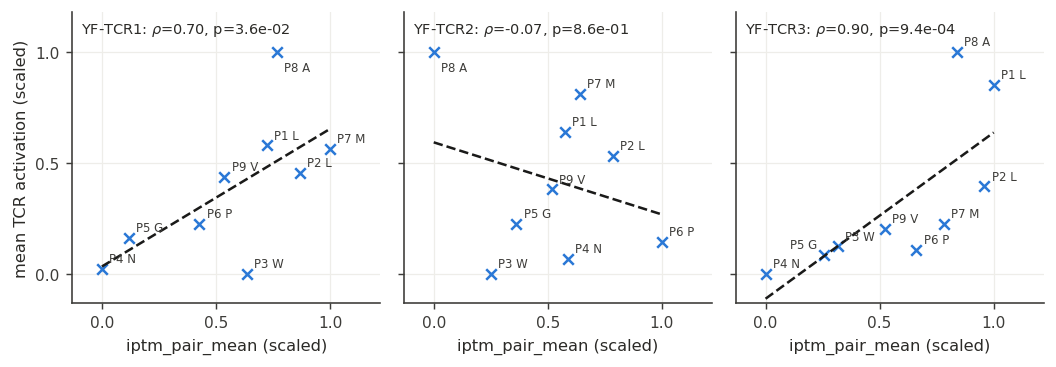

In [11]:
pos = (plot[~plot.is_wt]
       .groupby(["tcr", "mut_pos"], as_index=False)
       .agg(**{METRIC: (METRIC, "mean"), "ActivationScore": ("ActivationScore", "mean")}))
assert (pos.groupby("tcr").size() == 9).all(), "expected 9 positions per TCR"

# Label each point with its position and the wild-type residue there, e.g. "P8 A".
pos["lab"] = ["P" + str(int(p)) + " " + WT[int(p) - 1] for p in pos.mut_pos]

print(f"Per position ({METRIC}):")
scan_figure(pos, METRIC, "ActivationScore",
            "fig_scan_per_position.png",
            "mean TCR activation (scaled)", label_col="lab");

## 8. Experimental tolerance per position, averaged across the three TCRs

Each position is summarised by first taking that position's mean `ActivationScore`
within each TCR (18 substitutions each), then averaging those three values. Error bars
are **± 1 SD across the three TCRs**, so they show how reproducible a position's
tolerance is between TCRs — not the spread across substitutions, which is much larger.
The three per-TCR means are drawn behind the average so n = 3 is visible.

Values are raw percentages of the cognate response; nothing is scaled here.

In [12]:
def position_table(col, center=False):
    """Position means within each TCR, then averaged across TCRs.

    center=True subtracts each TCR's own across-position mean first, so the
    figure shows the position effect rather than per-TCR baseline offsets.
    """
    t = (plot[~plot.is_wt]
         .groupby(["tcr", "mut_pos"], as_index=False)
         .agg(v=(col, "mean")))
    assert len(t) == 27, "expected 3 TCRs x 9 positions"
    if center:
        t["v"] = t.v - t.groupby("tcr").v.transform("mean")
    a = (t.groupby("mut_pos")
         .agg(mean=("v", "mean"), sd=("v", "std"), n=("v", "size"))
         .reset_index())
    a["pos_label"] = [f"{WT[int(q) - 1]}{int(q)}" for q in a.mut_pos]
    return t, a

def position_figure(col, ylab, fname, center=False):
    per_tcr, agg = position_table(col, center)
    fig, ax = plt.subplots(figsize=(7.0, 3.4))
    xi = np.arange(9)

    for k, tcr in enumerate(tcrs):                     # individual TCRs behind
        g = per_tcr[per_tcr.tcr == tcr].sort_values("mut_pos")
        ax.scatter(xi + (k - 1) * 0.13, g.v, s=16, color="#b9b8b3",
                   linewidth=0, zorder=2,
                   label="individual TCRs" if k == 0 else None)

    ax.errorbar(xi, agg["mean"], yerr=agg["sd"], fmt="o", ms=6,
                color=C_MARK, ecolor="#52514e", elinewidth=1.1, capsize=3.5,
                capthick=1.1, zorder=3, label="mean of 3 TCRs ± 1 SD")

    ax.set_xticks(xi, agg.pos_label)
    ax.set_xlabel("Position (wild-type residue)")
    ax.set_ylabel(ylab)
    ax.axhline(0, color="#d6d5d0", lw=0.8, zorder=1)
    ax.grid(axis="y", zorder=0)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    ax.legend(frameon=False, fontsize=8, loc="best")

    fig.tight_layout()
    fig.savefig(WD / fname, bbox_inches="tight", facecolor="white")
    plt.show()
    return agg

### Experimental activation

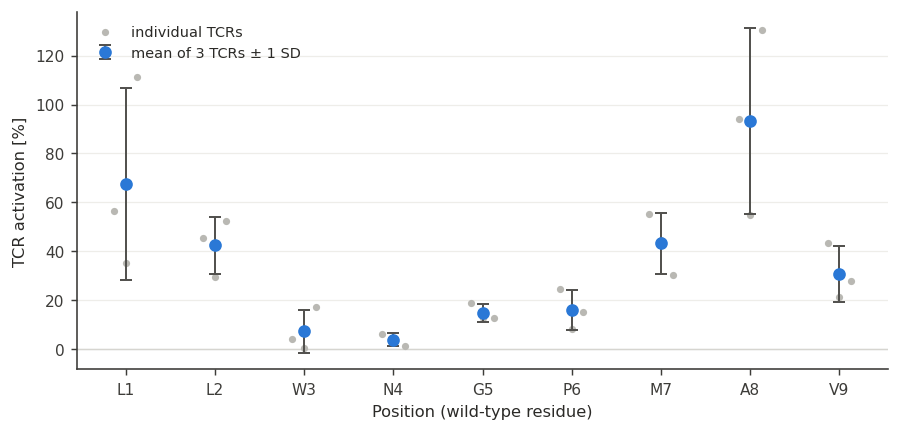

 mut_pos     mean       sd  n pos_label
    1.00    67.67    39.26  3        L1
    2.00    42.39    11.72  3        L2
    3.00     7.35     8.87  3        W3
    4.00     3.89     2.58  3        N4
    5.00    14.76     3.71  3        G5
    6.00    16.02     8.14  3        P6
    7.00    43.30    12.46  3        M7
    8.00    93.20    37.93  3        A8
    9.00    30.80    11.46  3        V9


In [13]:
agg_act = position_figure("ActivationScore", "TCR activation [%]",
                          "fig_activation_per_position.png")
print(agg_act.to_string(index=False, float_format=lambda v: f"{v:8.2f}"))

### Predicted ipTM, same layout

The three TCRs sit at different absolute ipTM levels, and that between-TCR offset is
larger than the whole position-to-position spread — so raw ipTM averaged across TCRs is
all baseline and no signal. Each TCR is therefore centred on its own across-position
mean first: the points then show the **position effect** and the error bars show how
well the three TCRs agree on it.

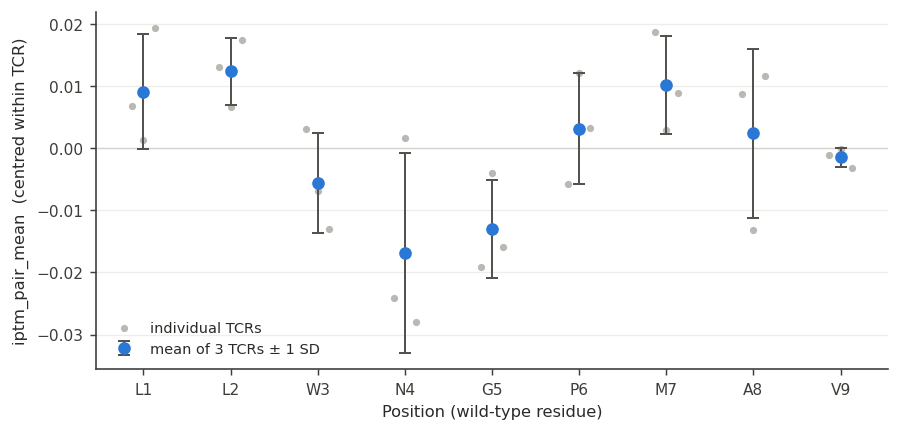

 mut_pos     mean       sd  n pos_label
  1.0000   0.0091   0.0092  3        L1
  2.0000   0.0123   0.0054  3        L2
  3.0000  -0.0056   0.0081  3        W3
  4.0000  -0.0168   0.0161  3        N4
  5.0000  -0.0130   0.0079  3        G5
  6.0000   0.0031   0.0089  3        P6
  7.0000   0.0102   0.0079  3        M7
  8.0000   0.0024   0.0136  3        A8
  9.0000  -0.0015   0.0016  3        V9

per-TCR baseline iptm_pair_mean (why centring is needed):
tcr
TCR_YF    0.7370
TCR_YF2   0.7595
TCR_YF3   0.7007
  between-TCR spread : 0.0588
  position spread    : 0.0291


In [14]:
agg_iptm_c = position_figure(METRIC, f"{METRIC}  (centred within TCR)",
                             "fig_iptm_per_position_centered.png", center=True)
print(agg_iptm_c.to_string(index=False, float_format=lambda v: f"{v:8.4f}"))

base = plot[~plot.is_wt].groupby("tcr")[METRIC].mean()
print(f"\nper-TCR baseline {METRIC} (why centring is needed):")
print(base.to_string(float_format=lambda v: f"{v:.4f}"))
print(f"  between-TCR spread : {base.max() - base.min():.4f}")
print(f"  position spread    : {agg_iptm_c['mean'].max() - agg_iptm_c['mean'].min():.4f}")

## 9. The two position profiles against each other

The 9 cross-TCR mean activations against the 9 cross-TCR mean ipTMs — one point per
peptide position, each already averaged over 3 TCRs x 18 substitutions.

Centring changes nothing here: it subtracts a per-TCR constant before averaging, which
shifts all nine positions by the same amount, so rho and R are identical whether the raw
or the centred ipTM means are used. It is verified below rather than asserted.

In [15]:
from scipy.stats import pearsonr

_, agg_raw = position_table(METRIC, center=False)

comp = (agg_act[["mut_pos", "pos_label", "mean"]].rename(columns={"mean": "act"})
        .merge(agg_iptm_c[["mut_pos", "mean"]].rename(columns={"mean": "iptm_c"}), on="mut_pos")
        .merge(agg_raw[["mut_pos", "mean"]].rename(columns={"mean": "iptm_raw"}), on="mut_pos"))

rho_c,  p_rho_c  = spearmanr(comp.iptm_c,   comp.act)
rho_r,  p_rho_r  = spearmanr(comp.iptm_raw, comp.act)
r_c,    p_r_c    = pearsonr(comp.iptm_c,    comp.act)
assert abs(rho_c - rho_r) < 1e-12, "centring should not change the across-position rho"
print(f"centred vs raw ipTM means differ by a constant: "
      f"{(comp.iptm_raw - comp.iptm_c).round(6).unique()}")
print(f"\nSpearman rho = {rho_c:.3f}  (p = {p_rho_c:.3g})   [identical for raw: {rho_r:.3f}]")
print(f"Pearson   R  = {r_c:.3f}  (p = {p_r_c:.3g})\n")
print(comp.to_string(index=False, float_format=lambda v: f"{v:9.4f}"))

centred vs raw ipTM means differ by a constant: [0.7324]

Spearman rho = 0.717  (p = 0.0298)   [identical for raw: 0.717]
Pearson   R  = 0.614  (p = 0.0785)

  mut_pos pos_label       act    iptm_c  iptm_raw
   1.0000        L1   67.6687    0.0091    0.7415
   2.0000        L2   42.3896    0.0123    0.7447
   3.0000        W3    7.3548   -0.0056    0.7268
   4.0000        N4    3.8880   -0.0168    0.7156
   5.0000        G5   14.7648   -0.0130    0.7194
   6.0000        P6   16.0248    0.0031    0.7355
   7.0000        M7   43.3013    0.0102    0.7426
   8.0000        A8   93.1987    0.0024    0.7348
   9.0000        V9   30.8017   -0.0015    0.7309


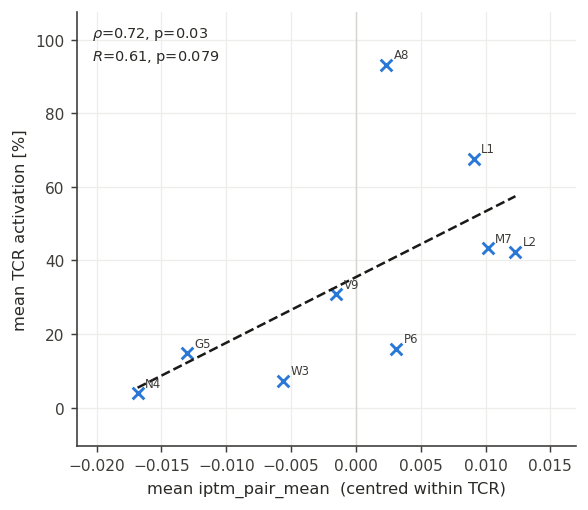

In [16]:
fig, ax = plt.subplots(figsize=(4.6, 4.0))

x, y = comp.iptm_c.values, comp.act.values
ax.scatter(x, y, marker="x", s=42, linewidth=1.6, color=C_MARK, zorder=3)

b, a = np.polyfit(x, y, 1)
xl = np.linspace(x.min(), x.max(), 50)
ax.plot(xl, a + b * xl, ls="--", lw=1.4, color="#1a1a19", zorder=4)

ax.axvline(0, color="#d6d5d0", lw=0.8, zorder=1)
ax.text(0.03, 0.97, f"$\\rho$={rho_c:.2f}, p={p_rho_c:.2g}\n$R$={r_c:.2f}, p={p_r_c:.2g}",
        transform=ax.transAxes, ha="left", va="top", fontsize=8, linespacing=1.5)

ax.set_xlabel(f"mean {METRIC}  (centred within TCR)")
ax.set_ylabel("mean TCR activation [%]")
ax.grid(True, zorder=0)
ax.set_axisbelow(True)
ax.margins(0.16)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)

fig.tight_layout()
place_labels(ax, x, y, comp.pos_label.tolist())
fig.savefig(WD / "fig_position_means_correlation.png", bbox_inches="tight",
            facecolor="white")
plt.show()